# <span style='color:Red'>Figure maker</span>

## <span style='color:Red'>Libraries, functions, paths</span>

In [1]:
import sys, os
from pathlib import Path

currentWD = os.path.dirname(Path.cwd())
if currentWD not in sys.path:
    sys.path.append(currentWD)
#print(sys.path)

import numpy, os, pandas, re, ast, seaborn, jlib
from matplotlib import pyplot

saveFigs = True
imagePath = 'img/final/'
imageFormats = ['svg','pdf']
exportsPath = 'exports/'

significanceSize = 14

desiredEffectSize = 'ges'

paletteBase = {'Chunkable':'#a1c9f4','Non-chunkable':'#ffb482'}
paletteInformative = {'Chunkable':'#7ca3cc','Non-chunkable':'#d68e5d'}
paletteUninformative = {'Chunkable':'#c7f0ff','Non-chunkable':'#ffdba8'}
paletteIUCombined = {'Chunkable\nInformative':"#7ca3cc",'Non-chunkable\nInformative':"#d68e5d",
                     'Chunkable\nUninformative':"#c7f0ff",'Non-chunkable\nUninformative':"#ffdba8"}

if not os.path.exists(imagePath):
    os.makedirs(imagePath)

mapValueHandler = jlib.data.mapValueHandler.MapValueHandler(exportsPath+"exp4Values.csv")

allParticipantData = pandas.read_csv(exportsPath+'participantData_long.csv')
allParticipantData.drop(['Mouse X path','Mouse Y path'],axis=1,inplace=True)

## <span style='color:Red'>Figure 4</span>

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: package 'jmv' was built under R version 4.4.3 



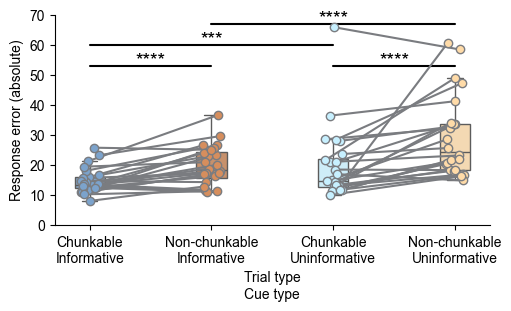

In [2]:
minAccuracyValue = 0
maxAccuracyValue = 1.2

minErrorOverBlocksValue = 0
maxErrorOverBlocksValue = 70

medianGroupedData = allParticipantData.copy()
medianGroupedData = medianGroupedData.groupby(['Subject','Trial type','Cue type']).median().reset_index()

errCTrialICueData = medianGroupedData[(medianGroupedData['Cue type']=='Informative') &
                                      (medianGroupedData['Trial type']=='Chunkable')]['Response error (absolute)'].to_numpy()
errNCTrialICueData = medianGroupedData[(medianGroupedData['Cue type']=='Informative') &
                                       (medianGroupedData['Trial type']=='Non-chunkable')]['Response error (absolute)'].to_numpy()

errCTrialUCueData = medianGroupedData[(medianGroupedData['Cue type']=='Uninformative') &
                                      (medianGroupedData['Trial type']=='Chunkable')]['Response error (absolute)'].to_numpy()
errNCTrialUCueData = medianGroupedData[(medianGroupedData['Cue type']=='Uninformative') &
                                         (medianGroupedData['Trial type']=='Non-chunkable')]['Response error (absolute)'].to_numpy()

errICueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                      column1=errNCTrialICueData,
                                                      column2=errCTrialICueData,
                                                      isStudent=False,isWilcoxon=True,hypothesis='oneGreater',
                                                      effectSize=True,descriptives=True)

errICueTtestPS['ttest'].columns = errICueTtestPS['ttest'].columns.str.rstrip('[wilc]')

errUCueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                      column1=errNCTrialUCueData,
                                                      column2=errCTrialUCueData,
                                                      isStudent=False,isWilcoxon=True,hypothesis='oneGreater',
                                                      effectSize=True,descriptives=True)

errUCueTtestPS['ttest'].columns = errUCueTtestPS['ttest'].columns.str.rstrip('[wilc]')

errCTrialTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                        column1=errCTrialUCueData,
                                                        column2=errCTrialICueData,
                                                        isStudent=False,isWilcoxon=True,hypothesis='oneGreater',
                                                        effectSize=True,descriptives=True)

errCTrialTtestPS['ttest'].columns = errCTrialTtestPS['ttest'].columns.str.rstrip('[wilc]')

errNCTrialTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                         column1=errNCTrialUCueData,
                                                         column2=errNCTrialICueData,
                                                         isStudent=False,isWilcoxon=True,hypothesis='oneGreater',
                                                         effectSize=True,descriptives=True)

errNCTrialTtestPS['ttest'].columns = errNCTrialTtestPS['ttest'].columns.str.rstrip('[wilc]')

# Create the figure
fig,ax = pyplot.subplots(1,1,figsize=(5,3),constrained_layout=True)
seaborn.set_style('ticks')

# Ax0,1: effect of chunking x cue (abs error)
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax,
                                            data=allParticipantData.groupby(['Subject','Trial type',
                                                                             'Cue type']).median().reset_index(),
                                            y='Response error (absolute)',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
seaborn.despine()
ax.set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)
jlib.display.utils.displayPairwiseSignificance(ax,[0,1],53*numpy.array([1,1]),size=significanceSize,
                                               p=2*errICueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax,[2,3],53*numpy.array([1,1]),size=significanceSize,
                                               p=2*errUCueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax,[0,2],60*numpy.array([1,1]),size=significanceSize,
                                               p=2*errCTrialTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax,[1,3],67*numpy.array([1,1]),size=significanceSize,
                                               p=2*errNCTrialTtestPS['ttest']['p'].to_numpy()[0])

C:\Users\juanm\AppData\Local\Temp\ipykernel_26160\3445174816.py:219: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax[1].get_xticklabels()])


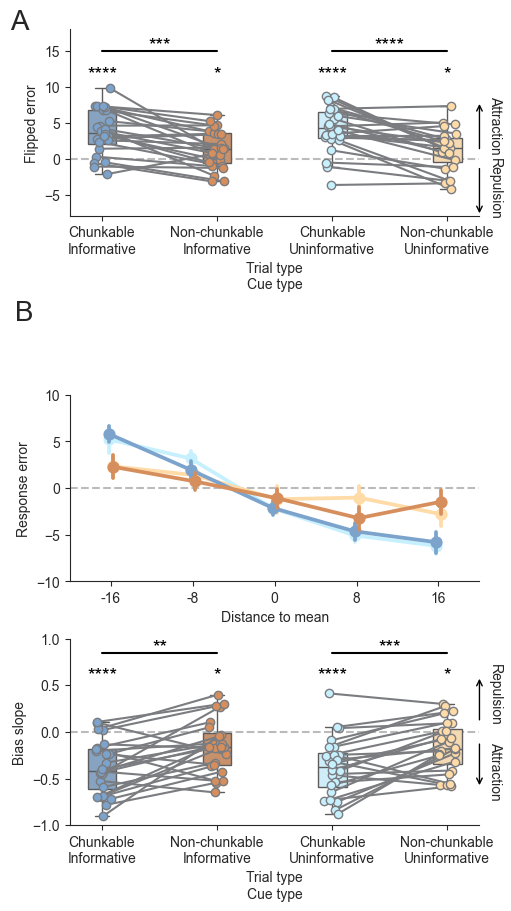

In [3]:
minBiasValue = -8
maxBiasValue = 18

columnsToKeep = ['Subject','Trial type','Response error','Flipped error','Cue type']

copyData = allParticipantData.copy()
copyData.drop([column for column in copyData.columns if column not in columnsToKeep],axis=1,inplace=True)

angleColumns = [column for column in copyData.columns if column not in ['Subject','Trial type','Cue type']]

copyGoodData = copyData.copy()
copyGoodData = copyGoodData[numpy.abs(copyGoodData['Response error'])<=40]

meanGoodCueData = copyGoodData.groupby(['Subject','Trial type','Cue type'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()

biasGoodNCTrialICueData = meanGoodCueData[(meanGoodCueData['Cue type']=='Informative') &
                                          (meanGoodCueData['Trial type']=='Non-chunkable')]['Flipped error'].to_numpy()
biasGoodCTrialICueData = meanGoodCueData[(meanGoodCueData['Cue type']=='Informative') &
                                         (meanGoodCueData['Trial type']=='Chunkable')]['Flipped error'].to_numpy()

biasGoodICueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           column1=biasGoodCTrialICueData,
                                                           column2=biasGoodNCTrialICueData,
                                                           isStudent=True,isWilcoxon=False,hypothesis='different',
                                                           effectSize=True,descriptives=True)

biasGoodICueTtestPS['ttest'].columns = biasGoodICueTtestPS['ttest'].columns.str.rstrip('[stud]')

biasGoodICueTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           variables=[biasGoodCTrialICueData,
                                                                      biasGoodNCTrialICueData],
                                                           testValue=0,isStudent=True,isWilcoxon=False,hypothesis='gt',
                                                           effectSize=True,descriptives=True)

biasGoodICueTtestOS['ttest'].columns = biasGoodICueTtestOS['ttest'].columns.str.rstrip('[stud]')

biasGoodNCTrialUCueData = meanGoodCueData[(meanGoodCueData['Cue type']=='Uninformative') &
                                           (meanGoodCueData['Trial type']=='Non-chunkable')]['Flipped error'].to_numpy()
biasGoodCTrialUCueData = meanGoodCueData[(meanGoodCueData['Cue type']=='Uninformative') &
                                        (meanGoodCueData['Trial type']=='Chunkable')]['Flipped error'].to_numpy()

biasGoodUCueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           column1=biasGoodCTrialUCueData,
                                                           column2=biasGoodNCTrialUCueData,
                                                           isStudent=True,isWilcoxon=False,hypothesis='different',
                                                           effectSize=True,descriptives=True)

biasGoodUCueTtestPS['ttest'].columns = biasGoodUCueTtestPS['ttest'].columns.str.rstrip('[stud]')

biasGoodUCueTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           variables=[biasGoodCTrialUCueData,
                                                                      biasGoodNCTrialUCueData],
                                                           testValue=0,isStudent=True,isWilcoxon=False,hypothesis='gt',
                                                           effectSize=True,descriptives=True)

biasGoodUCueTtestOS['ttest'].columns = biasGoodUCueTtestOS['ttest'].columns.str.rstrip('[stud]')

minErrorDistanceValue = -10
maxErrorDistanceValue = 10

distCopyData = allParticipantData.copy()
nTargets = numpy.unique(distCopyData['Target']).shape[0]

distCopyData['Distance to mean'] = distCopyData.apply(
    lambda x: jlib.compression.experimentValues.splitByDistanceToMean(x,5,
                                                                      jlib.compression.constants.EXP4_OFFSET_ANGLE,
                                                                      nTargets,
                                                                      jlib.compression.constants.EXP4_RESPONSE_SECTIONS,
                                                                      expType='Exp4'),axis=1)

columnsToKeep = ['Subject','Trial type','Response error','Flipped error','Cue type','Distance to mean']
distCopyData.drop([column for column in distCopyData.columns if column not in columnsToKeep],axis=1,inplace=True)

distGoodCopyData = distCopyData.copy()
distGoodCopyData = distGoodCopyData[numpy.abs(distGoodCopyData['Response error'])<=40]

distGoodCueMeanData = distGoodCopyData.groupby(['Subject','Trial type','Cue type','Distance to mean'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()

minSlopeValue = -1
maxSlopeValue = 1

columnsToKeep = ['Subject','Trial type','Response error','True target','Cue type']

distGoodModelData = allParticipantData.copy()
distGoodModelData = distGoodModelData[numpy.abs(distGoodModelData['Response error'])<=40]
distGoodModelData['True target'] = (distGoodModelData['Continuous target']-distGoodModelData['Mean target'])/3
distGoodModelData.drop([column for column in distGoodModelData.columns if column not in columnsToKeep],axis=1,inplace=True)

allFitsC_I = []
allFitsC_U = []
allFitsNC_I = []
allFitsNC_U = []

optimizationBounds = (numpy.array([-numpy.inf,-numpy.inf]),numpy.array([numpy.inf,numpy.inf]))

for participant in numpy.unique(distGoodModelData['Subject']):
    participantModelData = distGoodModelData[distGoodModelData['Subject']==participant]
    # print('Fitting data for participant',participant)
    # Fit chunkable trials / informative cue
    xC_I = participantModelData[(participantModelData['Trial type']=='Chunkable') &
                                (participantModelData['Cue type']=='Informative')]['True target'].to_numpy()
    yC_I = participantModelData[(participantModelData['Trial type']=='Chunkable') &
                                (participantModelData['Cue type']=='Informative')]['Response error'].to_numpy()
    fitStartingPointC_I = [0,numpy.mean(yC_I)]
    fitC_I = jlib.analysis.models.fitLine(xC_I,yC_I,fitStartingPointC_I,optimizationBounds)
    allFitsC_I.append(fitC_I.x)
    # Fit chunkable trials / uninformative cue
    xC_U = participantModelData[(participantModelData['Trial type']=='Chunkable') &
                                (participantModelData['Cue type']=='Uninformative')]['True target'].to_numpy()
    yC_U = participantModelData[(participantModelData['Trial type']=='Chunkable') &
                                (participantModelData['Cue type']=='Uninformative')]['Response error'].to_numpy()
    fitStartingPointC_U = [0,numpy.mean(yC_U)]
    fitC_U = jlib.analysis.models.fitLine(xC_U,yC_U,fitStartingPointC_U,optimizationBounds)
    allFitsC_U.append(fitC_U.x)
    # Fit non-chunkable trials / informative cue
    xNC_I = participantModelData[(participantModelData['Trial type']=='Non-chunkable') &
                                 (participantModelData['Cue type']=='Informative')]['True target'].to_numpy()
    yNC_I = participantModelData[(participantModelData['Trial type']=='Non-chunkable') &
                                 (participantModelData['Cue type']=='Informative')]['Response error'].to_numpy()
    fitStartingPointNC_I = [0,numpy.mean(yNC_I)]
    fitNC_I = jlib.analysis.models.fitLine(xNC_I,yNC_I,fitStartingPointNC_I,optimizationBounds)
    allFitsNC_I.append(fitNC_I.x)
    # Fit non-chunkable trials / informative cue
    xNC_U = participantModelData[(participantModelData['Trial type']=='Non-chunkable') &
                                 (participantModelData['Cue type']=='Uninformative')]['True target'].to_numpy()
    yNC_U = participantModelData[(participantModelData['Trial type']=='Non-chunkable') &
                                 (participantModelData['Cue type']=='Uninformative')]['Response error'].to_numpy()
    fitStartingPointNC_U = [0,numpy.mean(yNC_U)]
    fitNC_U = jlib.analysis.models.fitLine(xNC_U,yNC_U,fitStartingPointNC_U,optimizationBounds)
    allFitsNC_U.append(fitNC_U.x)

allFitsC_I = numpy.array(allFitsC_I)
allFitsC_U = numpy.array(allFitsC_U)
allFitsNC_I = numpy.array(allFitsNC_I)
allFitsNC_U = numpy.array(allFitsNC_U)

biasSlopesNCTrialICue = allFitsNC_I[:,0]
biasSlopesCTrialICue = allFitsC_I[:,0]

biasSlopeICueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                            column1=biasSlopesNCTrialICue,column2=biasSlopesCTrialICue,
                                                            isStudent=True,isWilcoxon=False,hypothesis='different',
                                                            effectSize=True,descriptives=True)

biasSlopeICueTtestPS['ttest'].columns = biasSlopeICueTtestPS['ttest'].columns.str.rstrip('[stud]')

biasSlopeICueTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                            variables=[biasSlopesCTrialICue,biasSlopesNCTrialICue],
                                                            testValue=0,isStudent=True,isWilcoxon=False,hypothesis='lt',
                                                            effectSize=True,descriptives=True)

biasSlopeICueTtestOS['ttest'].columns = biasSlopeICueTtestOS['ttest'].columns.str.rstrip('[stud]')

biasSlopesNCTrialUCue = allFitsNC_U[:,0]
biasSlopesCTrialUCue = allFitsC_U[:,0]

biasSlopeUCueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                            column1=biasSlopesNCTrialUCue,column2=biasSlopesCTrialUCue,
                                                            isStudent=True,isWilcoxon=False,hypothesis='different',
                                                            effectSize=True,descriptives=True)

biasSlopeUCueTtestPS['ttest'].columns = biasSlopeUCueTtestPS['ttest'].columns.str.rstrip('[stud]')

biasSlopeUCueTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                            variables=[biasSlopesCTrialUCue,biasSlopesNCTrialUCue],
                                                            testValue=0,isStudent=True,isWilcoxon=False,hypothesis='lt',
                                                            effectSize=True,descriptives=True)

biasSlopeUCueTtestOS['ttest'].columns = biasSlopeUCueTtestOS['ttest'].columns.str.rstrip('[stud]')

# Create the figure
fig,ax = pyplot.subplots(3,1,figsize=(5,9),constrained_layout=True)
seaborn.set_style('ticks')

# Ax[0]: bias as function of chunking/cue
ax[0].plot([-0.28,3.28],[0,0],'--',color='#bbbbbb')
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax[0],
                                            data=meanGoodCueData,
                                            y='Flipped error',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
# ax[0].set_ylabel("")
ax[0].set_ylim(minBiasValue,maxBiasValue)
ax[0].set_xlim(-0.28,3.28)
jlib.display.utils.displayPairwiseSignificance(ax[0],[0,1],15*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasGoodICueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax[0],[2,3],15*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasGoodUCueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax[0],0,11,size=significanceSize,
                                                p=2*biasGoodICueTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax[0],1,11,size=significanceSize,
                                                p=2*biasGoodICueTtestOS['ttest']['p'].to_numpy()[1])
jlib.display.utils.displayOneSampleSignificance(ax[0],2,11,size=significanceSize,
                                                p=2*biasGoodUCueTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax[0],3,11,size=significanceSize,
                                                p=2*biasGoodUCueTtestOS['ttest']['p'].to_numpy()[1])
ax[0].annotate('',xy=(1,0),xytext=(1,7/26),xycoords='axes fraction',textcoords='axes fraction',
               ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax[0].annotate('Attraction',xy=(0,0),xytext=(1.02,9/26),textcoords='axes fraction',rotation=-90)
ax[0].annotate('',xy=(1,16/26),xytext=(1,9/26),xycoords='axes fraction',textcoords='axes fraction',
               ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax[0].annotate('Repulsion',xy=(0,0),xytext=(1.02,0),textcoords='axes fraction',rotation=-90)
ax[0].text(-0.8,18,'A',fontsize=20)

# Ax[1]: bias as a function of distance to mean
ax[1].plot([-0.5,4.5],[0,0],'--',color='#bbbbbb')
seaborn.pointplot(ax=ax[1],
                  data=distGoodCueMeanData[distGoodCueMeanData['Cue type']=='Uninformative'],
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,legend=False,estimator=numpy.nanmean,palette=paletteUninformative)
seaborn.pointplot(ax=ax[1],
                  data=distGoodCueMeanData[distGoodCueMeanData['Cue type']=='Informative'],
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,legend=False,estimator=numpy.nanmean,palette=paletteInformative)
ax[1].set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax[1].get_xticklabels()])
ax[1].set_ylim(minErrorDistanceValue,maxErrorDistanceValue)
ax[1].set_xlim(-0.5,4.5)
ax[1].text(-1.17,18,'B',fontsize=20)

# Ax[2]: bias slopes
ax[2].plot([-0.28,3.28],[0,0],'--',color='#bbbbbb')
biasGoodInsetDF = meanGoodCueData.copy()
biasGoodInsetDF['Bias slope'] = [x for group in zip(biasSlopesCTrialICue,biasSlopesCTrialUCue,biasSlopesNCTrialICue,biasSlopesNCTrialUCue) for x in group]
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax[2],
                                            data=biasGoodInsetDF,
                                            y='Bias slope',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
ax[2].set_ylim(minSlopeValue,maxSlopeValue)
ax[2].set_xlim(-0.28,3.28)
jlib.display.utils.displayPairwiseSignificance(ax[2],[0,1],0.85*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasSlopeICueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax[2],[2,3],0.85*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasSlopeUCueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax[2],0,0.55,size=significanceSize,
                                                p=2*biasSlopeICueTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax[2],1,0.55,size=significanceSize,
                                                p=2*biasSlopeICueTtestOS['ttest']['p'].to_numpy()[1])
jlib.display.utils.displayOneSampleSignificance(ax[2],2,0.55,size=significanceSize,
                                                p=2*biasSlopeUCueTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax[2],3,0.55,size=significanceSize,
                                                p=2*biasSlopeUCueTtestOS['ttest']['p'].to_numpy()[1])
ax[2].annotate('',xy=(1,0.2),xytext=(1,0.45),xycoords='axes fraction',textcoords='axes fraction',
               ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax[2].annotate('Attraction',xy=(0,0),xytext=(1.02,0.15),textcoords='axes fraction',rotation=-90)
ax[2].annotate('',xy=(1,0.8),xytext=(1,0.55),xycoords='axes fraction',textcoords='axes fraction',
               ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax[2].annotate('Repulsion',xy=(0,0),xytext=(1.02,0.55),textcoords='axes fraction',rotation=-90)

seaborn.despine()

C:\Users\juanm\AppData\Local\Temp\ipykernel_26160\3472334215.py:129: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation=35, ha='right', rotation_mode='anchor')
C:\Users\juanm\AppData\Local\Temp\ipykernel_26160\3472334215.py:142: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(),rotation=35,ha='right',rotation_mode='anchor')
C:\Users\juanm\AppData\Local\Temp\ipykernel_26160\3472334215.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(),rotation=35,ha='right',rotation_mode='anchor')


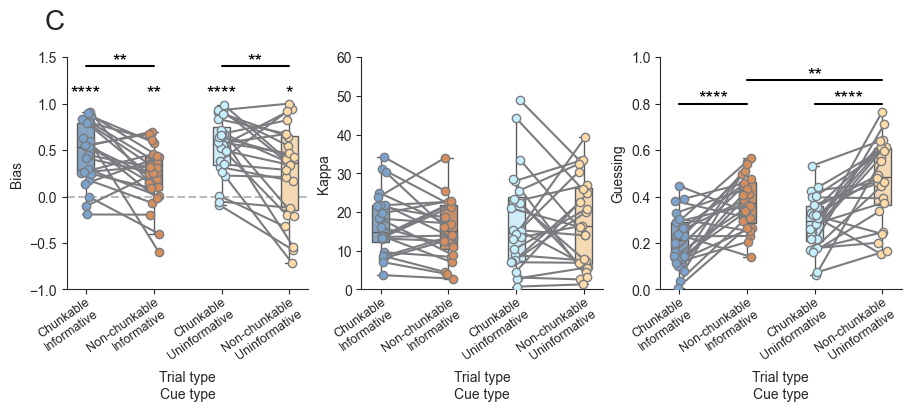

In [4]:
exportsPathTemp = 'exports/biasModels/temp/full/'
import pickle

with open(exportsPathTemp+'allFitsChunkingI.pkl','rb') as fp:
    allFitsChunkingI = pickle.load(fp)
with open(exportsPathTemp+'allBICChunkingI.pkl','rb') as fp:
    allBICChunkingI = pickle.load(fp)
with open(exportsPathTemp+'allFitsChunkingU.pkl','rb') as fp:
    allFitsChunkingU = pickle.load(fp)
with open(exportsPathTemp+'allBICChunkingU.pkl','rb') as fp:
    allBICChunkingU = pickle.load(fp)
with open(exportsPathTemp+'allFitsNonChunkingI.pkl','rb') as fp:
    allFitsNonChunkingI = pickle.load(fp)
with open(exportsPathTemp+'allBICNonChunkingI.pkl','rb') as fp:
    allBICNonChunkingI = pickle.load(fp)
with open(exportsPathTemp+'allFitsNonChunkingU.pkl','rb') as fp:
    allFitsNonChunkingU = pickle.load(fp)
with open(exportsPathTemp+'allBICNonChunkingU.pkl','rb') as fp:
    allBICNonChunkingU = pickle.load(fp)

chunkingIParams = {}
chunkingUParams = {}
nonChunkingIParams = {}
nonChunkingUParams = {}

for participant in allFitsChunkingI['Bias']:
    for param in allFitsChunkingI['Bias'][participant][0].keys():
        if (param not in chunkingIParams):
            chunkingIParams[param] = []
            chunkingUParams[param] = []
            nonChunkingIParams[param] = []
            nonChunkingUParams[param] = []
        chunkingIParams[param].append(allFitsChunkingI['Bias'][participant][0][param])
        chunkingUParams[param].append(allFitsChunkingU['Bias'][participant][0][param])
        nonChunkingIParams[param].append(allFitsNonChunkingI['Bias'][participant][0][param])
        nonChunkingUParams[param].append(allFitsNonChunkingU['Bias'][participant][0][param])

biasICueFitsTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           variables=[chunkingIParams['bias'],nonChunkingIParams['bias']],
                                                           testValue=0,isStudent=True,isWilcoxon=False,hypothesis='dt',
                                                           effectSize=True,descriptives=True)

biasICueFitsTtestOS['ttest'].columns = biasICueFitsTtestOS['ttest'].columns.str.rstrip('[stud]')

biasICueFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           column1=chunkingIParams['bias'],
                                                           column2=nonChunkingIParams['bias'],
                                                           isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                           effectSize=True,descriptives=True)

biasICueFitsTtestPS['ttest'].columns = biasICueFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

biasUCueFitsTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           variables=[chunkingUParams['bias'],nonChunkingUParams['bias']],
                                                           testValue=0,isStudent=True,isWilcoxon=False,hypothesis='dt',
                                                           effectSize=True,descriptives=True)

biasUCueFitsTtestOS['ttest'].columns = biasUCueFitsTtestOS['ttest'].columns.str.rstrip('[stud]')

biasUCueFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           column1=chunkingUParams['bias'],
                                                           column2=nonChunkingUParams['bias'],
                                                           isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                           effectSize=True,descriptives=True)

biasUCueFitsTtestPS['ttest'].columns = biasUCueFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

guessingNCTrialFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                                  column1=nonChunkingUParams['guessingP'],
                                                                  column2=nonChunkingIParams['guessingP'],
                                                                  isStudent=True,isWilcoxon=False,hypothesis='different',
                                                                  effectSize=True,descriptives=True)

guessingNCTrialFitsTtestPS['ttest'].columns = guessingNCTrialFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

guessingUCueFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                            column1=nonChunkingUParams['guessingP'],
                                                            column2=chunkingUParams['guessingP'],
                                                            isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                            effectSize=True,descriptives=True)

guessingUCueFitsTtestPS['ttest'].columns = guessingUCueFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

guessingICueFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                               column1=nonChunkingIParams['guessingP'],
                                                               column2=chunkingIParams['guessingP'],
                                                               isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                               effectSize=True,descriptives=True)

guessingICueFitsTtestPS['ttest'].columns = guessingICueFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

# Create the figure
fig,ax = pyplot.subplot_mosaic([['E','E','F','F','G','G']],
                               figsize=(9,4),constrained_layout=True)
seaborn.set_style('ticks')

# Ax[2,0]: bias parameter
ax['E'].plot([-0.28,3.28],[0,0],'--',color='#bbbbbb')
plottingDictionary = {'Subject':numpy.tile(numpy.unique(allParticipantData['Subject']),4),
                      'Trial type':numpy.tile(['Chunkable']*len(chunkingIParams['bias'])+['Non-chunkable']*len(chunkingIParams['bias']),2),
                      'Cue type':['Informative']*2*len(chunkingIParams['bias'])+['Uninformative']*2*len(chunkingIParams['bias']),
                      'Bias':chunkingIParams['bias']+nonChunkingIParams['bias']+chunkingUParams['bias']+nonChunkingUParams['bias'],
                      'Guessing':chunkingIParams['guessingP']+nonChunkingIParams['guessingP']+chunkingUParams['guessingP']+nonChunkingUParams['guessingP'],
                      'Kappa':chunkingIParams['kappa']+nonChunkingIParams['kappa']+chunkingUParams['kappa']+nonChunkingUParams['kappa']}
plottingDF = pandas.DataFrame.from_dict(plottingDictionary)
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax['E'],
                                            data=plottingDF,
                                            y='Bias',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
ax['E'].set_xlim(-0.28,3.28)
ax['E'].set_ylim(-1,1.5)
jlib.display.utils.displayPairwiseSignificance(ax['E'],[0,1],1.4*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasICueFitsTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax['E'],[2,3],1.4*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasUCueFitsTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['E'],0,1.05,size=significanceSize,
                                                p=2*biasICueFitsTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['E'],1,1.05,size=significanceSize,
                                                p=2*biasICueFitsTtestOS['ttest']['p'].to_numpy()[1])
jlib.display.utils.displayOneSampleSignificance(ax['E'],2,1.05,size=significanceSize,
                                                p=2*biasUCueFitsTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['E'],3,1.05,size=significanceSize,
                                                p=2*biasUCueFitsTtestOS['ttest']['p'].to_numpy()[1])
ax['E'].text(-0.6,1.8,'C',fontsize=20)
for a in [ax['E']]:
    a.set_xticklabels(a.get_xticklabels(), rotation=35, ha='right', rotation_mode='anchor')
    a.tick_params(axis='x', labelsize=9, pad=1)

# Ax[2,1]: kappa parameter
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax['F'],
                                            data=plottingDF,
                                            y='Kappa',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
ax['F'].set_ylim(0,60)
for a in [ax['F']]:  # or iterate your axes
    a.set_xticklabels(a.get_xticklabels(),rotation=35,ha='right',rotation_mode='anchor')
    a.tick_params(axis='x',labelsize=9,pad=1)

# Ax[2,2]: guessing parameter
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax['G'],
                                            data=plottingDF,
                                            y='Guessing',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
ax['G'].set_ylim(0,1)
jlib.display.utils.displayPairwiseSignificance(ax['G'],[1,3],0.9*numpy.array([1,1]),size=significanceSize,
                                               p=2*guessingNCTrialFitsTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax['G'],[0,1],0.8*numpy.array([1,1]),size=significanceSize,
                                               p=2*guessingICueFitsTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax['G'],[2,3],0.8*numpy.array([1,1]),size=significanceSize,
                                               p=2*guessingUCueFitsTtestPS['ttest']['p'].to_numpy()[0])
for a in [ax['G']]:  # or iterate your axes
    a.set_xticklabels(a.get_xticklabels(),rotation=35,ha='right',rotation_mode='anchor')
    a.tick_params(axis='x',labelsize=9,pad=1)

seaborn.despine()

C:\Users\juanm\AppData\Local\Temp\ipykernel_26160\3459438353.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax['C'].set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax['C'].get_xticklabels()])
C:\Users\juanm\AppData\Local\Temp\ipykernel_26160\3459438353.py:142: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation=35, ha='right', rotation_mode='anchor')
C:\Users\juanm\AppData\Local\Temp\ipykernel_26160\3459438353.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(),rotation=35,ha='right',rotation_mode='anchor')
C:\Users\juanm\AppData\Local\Temp\ipykernel_26160\3459438353.py:174: UserWarning: set_ticklabels() should only be used with

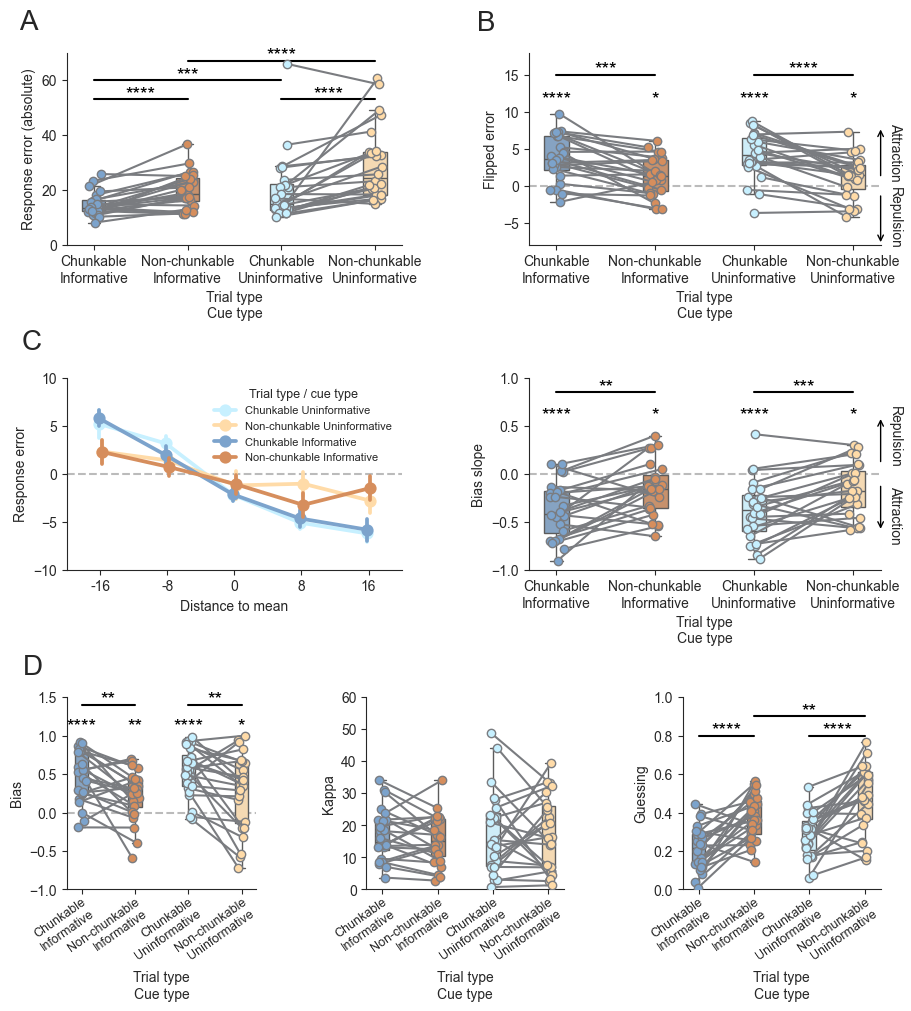

In [5]:
# Create the figure
fig,ax = pyplot.subplot_mosaic([['A','A','A','B','B','B'],['C','C','C','D','D','D'],['E','E','F','F','G','G']],
                               figsize=(9,10),constrained_layout=True)
seaborn.set_style('ticks')

# Ax0,1: effect of chunking x cue (abs error)
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax['A'],
                                            data=allParticipantData.groupby(['Subject','Trial type',
                                                                             'Cue type']).median().reset_index(),
                                            y='Response error (absolute)',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
ax['A'].set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)
ax['A'].text(-0.8,78.5,'A',fontsize=20)
jlib.display.utils.displayPairwiseSignificance(ax['A'],[0,1],53*numpy.array([1,1]),size=significanceSize,
                                               p=2*errICueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax['A'],[2,3],53*numpy.array([1,1]),size=significanceSize,
                                               p=2*errUCueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax['A'],[0,2],60*numpy.array([1,1]),size=significanceSize,
                                               p=2*errCTrialTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax['A'],[1,3],67*numpy.array([1,1]),size=significanceSize,
                                               p=2*errNCTrialTtestPS['ttest']['p'].to_numpy()[0])

# Ax[0]: bias as function of chunking/cue
ax['B'].plot([-0.28,3.28],[0,0],'--',color='#bbbbbb')
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax['B'],
                                            data=meanGoodCueData,
                                            y='Flipped error',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
# ax[0].set_ylabel("")
ax['B'].set_ylim(minBiasValue,maxBiasValue)
ax['B'].set_xlim(-0.28,3.28)
jlib.display.utils.displayPairwiseSignificance(ax['B'],[0,1],15*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasGoodICueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax['B'],[2,3],15*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasGoodUCueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['B'],0,11,size=significanceSize,
                                                p=2*biasGoodICueTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['B'],1,11,size=significanceSize,
                                                p=2*biasGoodICueTtestOS['ttest']['p'].to_numpy()[1])
jlib.display.utils.displayOneSampleSignificance(ax['B'],2,11,size=significanceSize,
                                                p=2*biasGoodUCueTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['B'],3,11,size=significanceSize,
                                                p=2*biasGoodUCueTtestOS['ttest']['p'].to_numpy()[1])
ax['B'].annotate('',xy=(1,0),xytext=(1,7/26),xycoords='axes fraction',textcoords='axes fraction',
               ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax['B'].annotate('Attraction',xy=(0,0),xytext=(1.02,9/26),textcoords='axes fraction',rotation=-90)
ax['B'].annotate('',xy=(1,16/26),xytext=(1,9/26),xycoords='axes fraction',textcoords='axes fraction',
               ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax['B'].annotate('Repulsion',xy=(0,0),xytext=(1.02,0),textcoords='axes fraction',rotation=-90)
ax['B'].text(-0.8,21,'B',fontsize=20)

# Ax[1]: bias as a function of distance to mean
ax['C'].plot([-0.5,4.5],[0,0],'--',color='#bbbbbb')
seaborn.pointplot(ax=ax['C'],
                  data=distGoodCueMeanData[distGoodCueMeanData['Cue type']=='Uninformative'],
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,legend=True,estimator=numpy.nanmean,palette=paletteUninformative)
seaborn.pointplot(ax=ax['C'],
                  data=distGoodCueMeanData[distGoodCueMeanData['Cue type']=='Informative'],
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,legend=True,estimator=numpy.nanmean,palette=paletteInformative)
ax['C'].set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax['C'].get_xticklabels()])
ax['C'].set_ylim(minErrorDistanceValue,maxErrorDistanceValue)
ax['C'].set_xlim(-0.5,4.5)
ax['C'].text(-1.17,13,'C',fontsize=20)
ax['C'].legend(title='Trial type / cue type',frameon=False,fontsize=8,title_fontsize=9)
leg = ax['C'].get_legend()
labels = ["Chunkable Uninformative","Non-chunkable Uninformative","Chunkable Informative","Non-chunkable Informative"]
for text, new_label in zip(leg.texts, labels):
    text.set_text(new_label)

# Ax[2]: bias slopes
ax['D'].plot([-0.28,3.28],[0,0],'--',color='#bbbbbb')
biasGoodInsetDF = meanGoodCueData.copy()
biasGoodInsetDF['Bias slope'] = [x for group in zip(biasSlopesCTrialICue,biasSlopesCTrialUCue,biasSlopesNCTrialICue,biasSlopesNCTrialUCue) for x in group]
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax['D'],
                                            data=biasGoodInsetDF,
                                            y='Bias slope',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
ax['D'].set_ylim(minSlopeValue,maxSlopeValue)
ax['D'].set_xlim(-0.28,3.28)
jlib.display.utils.displayPairwiseSignificance(ax['D'],[0,1],0.85*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasSlopeICueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax['D'],[2,3],0.85*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasSlopeUCueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['D'],0,0.55,size=significanceSize,
                                                p=2*biasSlopeICueTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['D'],1,0.55,size=significanceSize,
                                                p=2*biasSlopeICueTtestOS['ttest']['p'].to_numpy()[1])
jlib.display.utils.displayOneSampleSignificance(ax['D'],2,0.55,size=significanceSize,
                                                p=2*biasSlopeUCueTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['D'],3,0.55,size=significanceSize,
                                                p=2*biasSlopeUCueTtestOS['ttest']['p'].to_numpy()[1])
ax['D'].annotate('',xy=(1,0.2),xytext=(1,0.45),xycoords='axes fraction',textcoords='axes fraction',
               ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax['D'].annotate('Attraction',xy=(0,0),xytext=(1.02,0.15),textcoords='axes fraction',rotation=-90)
ax['D'].annotate('',xy=(1,0.8),xytext=(1,0.55),xycoords='axes fraction',textcoords='axes fraction',
               ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax['D'].annotate('Repulsion',xy=(0,0),xytext=(1.02,0.55),textcoords='axes fraction',rotation=-90)

# Ax[2,0]: bias parameter
ax['E'].plot([-0.28,3.28],[0,0],'--',color='#bbbbbb')
plottingDictionary = {'Subject':numpy.tile(numpy.unique(allParticipantData['Subject']),4),
                      'Trial type':numpy.tile(['Chunkable']*len(chunkingIParams['bias'])+['Non-chunkable']*len(chunkingIParams['bias']),2),
                      'Cue type':['Informative']*2*len(chunkingIParams['bias'])+['Uninformative']*2*len(chunkingIParams['bias']),
                      'Bias':chunkingIParams['bias']+nonChunkingIParams['bias']+chunkingUParams['bias']+nonChunkingUParams['bias'],
                      'Guessing':chunkingIParams['guessingP']+nonChunkingIParams['guessingP']+chunkingUParams['guessingP']+nonChunkingUParams['guessingP'],
                      'Kappa':chunkingIParams['kappa']+nonChunkingIParams['kappa']+chunkingUParams['kappa']+nonChunkingUParams['kappa']}
plottingDF = pandas.DataFrame.from_dict(plottingDictionary)
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax['E'],
                                            data=plottingDF,
                                            y='Bias',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
ax['E'].set_xlim(-0.28,3.28)
ax['E'].set_ylim(-1,1.5)
jlib.display.utils.displayPairwiseSignificance(ax['E'],[0,1],1.4*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasICueFitsTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax['E'],[2,3],1.4*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasUCueFitsTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['E'],0,1.05,size=significanceSize,
                                                p=2*biasICueFitsTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['E'],1,1.05,size=significanceSize,
                                                p=2*biasICueFitsTtestOS['ttest']['p'].to_numpy()[1])
jlib.display.utils.displayOneSampleSignificance(ax['E'],2,1.05,size=significanceSize,
                                                p=2*biasUCueFitsTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['E'],3,1.05,size=significanceSize,
                                                p=2*biasUCueFitsTtestOS['ttest']['p'].to_numpy()[1])
ax['E'].text(-1.1,1.8,'D',fontsize=20)
for a in [ax['E']]:
    a.set_xticklabels(a.get_xticklabels(), rotation=35, ha='right', rotation_mode='anchor')
    a.tick_params(axis='x', labelsize=9, pad=1)

# Ax[2,1]: kappa parameter
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax['F'],
                                            data=plottingDF,
                                            y='Kappa',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
ax['F'].set_ylim(0,60)
for a in [ax['F']]:  # or iterate your axes
    a.set_xticklabels(a.get_xticklabels(),rotation=35,ha='right',rotation_mode='anchor')
    a.tick_params(axis='x',labelsize=9,pad=1)

# Ax[2,2]: guessing parameter
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax['G'],
                                            data=plottingDF,
                                            y='Guessing',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
ax['G'].set_ylim(0,1)
jlib.display.utils.displayPairwiseSignificance(ax['G'],[1,3],0.9*numpy.array([1,1]),size=significanceSize,
                                               p=2*guessingNCTrialFitsTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax['G'],[0,1],0.8*numpy.array([1,1]),size=significanceSize,
                                               p=2*guessingICueFitsTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax['G'],[2,3],0.8*numpy.array([1,1]),size=significanceSize,
                                               p=2*guessingUCueFitsTtestPS['ttest']['p'].to_numpy()[0])
for a in [ax['G']]:  # or iterate your axes
    a.set_xticklabels(a.get_xticklabels(),rotation=35,ha='right',rotation_mode='anchor')
    a.tick_params(axis='x',labelsize=9,pad=1)

seaborn.despine()

if (saveFigs):
    for format in imageFormats:
        fig.savefig(imagePath+'exp4BehavBiasModel.'+format,format=format,dpi=1200)